## Лабораторная работа № 2 
## Машинное обучение на больших данных с использованием фреймворка Apache Spark и библиотеки SparkML

### Часть 1

В данной части работы рассмотрены:
* подготовка признаков для рашения задачи **линейной регрессии**;
* создание и обучение модели линейной регрессии;
* оценка качества модели.

#### Запуск `Spark`-сессии

Подключаем необходимые библиотеки.

In [1]:
import os
import csv
from pyspark.sql import SparkSession, DataFrame
from pyspark import SparkConf
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder, MinMaxScaler, Binarizer, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, CrossValidatorModel, ParamGridBuilder
from pyspark.ml import Pipeline
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType
import seaborn as sns
import matplotlib.pyplot as plt

Сформируем объект конфигурации для `Apache Spark`, указав необходимые параметры.

In [2]:
def create_spark_configuration() -> SparkConf:
    """
    Создает и конфигурирует экземпляр SparkConf для приложения Spark.

    Returns:
        SparkConf: Настроенный экземпляр SparkConf.
    """
    # Получаем имя пользователя
    # Получаем имя пользователя
    user_name = os.getenv("USER")
    
    conf = SparkConf()
    conf.setAppName("Lab_2_LR")
    conf.setMaster("local[*]")
    # conf.set("spark.submit.deployMode", "client")
    # КРИТИЧЕСКИЕ настройки памяти
    conf.set("spark.driver.memory", "8g")           # Увеличил драйвер
    conf.set("spark.executor.memory", "6g")         # Уменьшил исполнитель
    conf.set("spark.memory.fraction", "0.8")        # Больше для execution
    conf.set("spark.memory.storageFraction", "0.3") # Меньше для хранения
    
    # Настройки для больших данных
    conf.set("spark.sql.adaptive.enabled", "true")
    conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")
    conf.set("spark.sql.adaptive.skew.enabled", "true")
    conf.set("spark.sql.shuffle.partitions", "100")  # Уменьшил партиции
    
    conf.set("spark.sql.catalog.spark_catalog.type", "hadoop")
    conf.set("spark.sql.catalog.spark_catalog.warehouse", f"hdfs:///b")
    conf.set("spark.sql.catalog.spark_catalog.io-impl", "org.apache.iceberg.hadoop.HadoopFileIO")

    return conf

Создаём сам объект конфигурации.

In [3]:
conf = create_spark_configuration()

Создаём и выводим на экран сессию `Apache Spark`. В процессе создания сессии происходит подключение к кластеру `Apache Hadoop`, что может занять некоторое время.

In [4]:
spark = SparkSession.builder.config(conf=conf).getOrCreate()
spark

#### Загрузка датасета

In [5]:
database_name = "vasilev_database"
table_name = "books_table_past_exp"

output_path = f"hdfs://namenode:9000/b/{database_name}/{table_name}"

df = spark.read.parquet(output_path)

def print_df(df):
    return df.limit(20).toPandas().style\
    .set_properties(**{'text-align': 'left', 'max-width': '0', 'white-space': 'nowrap', 'overflow': 'hidden', 'text-overflow': 'ellipsis'})\
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])\
    .format(precision=2)

Выведем прочитанную таблицу на экран.

In [6]:
print_df(df)

,id,title,authors,publisher,published_date,categories,review_score,review_text,review_summary,review_helpfulness,review_time,user_id,profile_name,helpfulness_numerator,helpfulness_denominator,helpfulness_ratio,published_date_clean,authors_array,categories_array,published_year,author_count,category_count,is_helpful,has_multiple_authors,has_multiple_categories,is_recent_review,review_text_length,review_summary_length,title_length,review_year,review_month,publisher_type,main_category
0,0710509413,"""""""Chosen"""" Classics: Round the World in Eighty Days""",ship,China,and America in one of the wittiest,['Jules Verne'],3.00,"Jules verne the author of Round the World in Eighty Days, which is a good science-fiction book, takes you into the world of Phileas Fogg. He is an englishman who wanted tosail around the world in the shortest amount of time inhis time which would be in the 1800s.I didn�t really like this book it was the one when you just start to drift off to sleep, because it is so boring.",Round the World in Eighty Days,1/1,1016668800,None,Anonymous,1,1,1.00,None,[' ship'],['Jules Verne'],0,1,1,1,0,0,0,383,30,53,2002,3,other,other
1,0710509413,"""""""Chosen"""" Classics: Round the World in Eighty Days""",ship,China,and America in one of the wittiest,['Jules Verne'],3.00,I very like this book and i wont that you send me the books and i very thenk to you.,round the world in eighty days,0/2,972604800,A1KAHINMSASLMP,ytai,0,2,0.00,None,[' ship'],['Jules Verne'],0,1,1,0,0,0,0,84,30,53,2000,10,other,other
2,B000KO9Q6A,"""""""Fundamentalism"""" and the Word of God""",Unknown,Unknown,None,Unknown,4.00,"JI Packer wrote this book over 45 years ago. Some of the issues he addresses are not issues today. But the premise behind the book is timeless- the authority of the Word of God. Even though liberalism may not be as strong as it was 50 years ago, today Christendom is wandering farther and farther away from the authority of God?s Word. This fact can be seen in the growth of cults. It can also be seen in how Christians today depend on human authors instead of God?s Word. Yet another manifestation of this wrong notion is the branch of Christianity that replaces God?s Word with emotion and feelings. So though the issue of Liberalism may not be significant today, the issue of authority definitely is.I read the book for a class on ?The History of Fundamentalism in America?. The book does not really trace the history of Fundamentalism, but the book does cover the central issue in the Fundamentalism/Liberalism debate. Before reading the book, I would suggest reading the first two pages of the conclusion, where the author gives an overview of the entire book. The book is very logically laid out, with each chapter subject building on top of the last chapter subject. The only chapter I had problems with was the chapter on faith. The author tries to explain man?s inability to express faith, showing the author?s reformed presuppositions. I didn?t understand how this tied into the argument and flow of the book, and I think the notion is unbiblical (but this is a discussion for a different book review). The main argument of the book was one of presuppositions (as found in presuppositional apologetics). On page 109 the author writes, ?We should not abandon faith in anything that God has taught us merely because we cannot solve all the problems which it raises. Our own intellectual competence is not the test and measure of divine truth. It is not for us to stop believing because we lack understanding, or to postpone believing till we can get understanding, but to believe in order that we may understand?? This is the core issue of authority- are we going to trust our own minds, or are we going to trust God?s Word?I would recommend the book to any Christian. The book will challenge you to take on a stronger stance for the Word of God, and it will show the foolishness of doing otherwise.","Perhaps Oudated, But Solid",13/14,1072224000,AOHKH73SA3ZK7,Josh Mof

Анализ отзывов и рейтингов
| Название столбца | Расшифровка |
| -------- | ------ |
| id |	Уникальный идентификатор книги (ISBN/ASIN)
| title	| Название книги
| review_score	| Оценка книги пользователем (1.0-5.0)
| review_text	| Текст отзыва
| review_summary	| Заголовок отзыва
| review_helpfulness	| Полезность отзыва (в формате "X/Y")
| review_time	| Временная метка отзыва

Анализ книг и метаданных
| Название столбца | Расшифровка |
| -------- | ------ |
| authors	| Авторы книги
| publisher	| Издательство
| published_date	| Дата публикации книги
| categories	| Категории/жанры книги

Вспомним схему данных.

In [7]:
df.printSchema()

root
 |-- id: string (nullable = true)
 |-- title: string (nullable = true)
 |-- authors: string (nullable = true)
 |-- publisher: string (nullable = true)
 |-- published_date: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- review_score: double (nullable = true)
 |-- review_text: string (nullable = true)
 |-- review_summary: string (nullable = true)
 |-- review_helpfulness: string (nullable = true)
 |-- review_time: integer (nullable = true)
 |-- user_id: string (nullable = true)
 |-- profile_name: string (nullable = true)
 |-- helpfulness_numerator: integer (nullable = true)
 |-- helpfulness_denominator: integer (nullable = true)
 |-- helpfulness_ratio: double (nullable = true)
 |-- published_date_clean: date (nullable = true)
 |-- authors_array: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- categories_array: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- published_year: integer (nullable = true)
 |-

Вычислим количество строк в датафрейме.

In [8]:
df.count()

2981716

#### Постановка задачи линейной регрессии

Для датасета, заданного представленными колонками, требуется построить модель линейной регрессии для оценки **оценка отзыва** по всем остальным признакам. 

Для оценки качества обучения следует использовать метрики $RMSE$ и $R^2$.

#### Подготовка и кодирование признаков

Для корректной работы трансформеров преобразуем столбец `review_score` к типу `DoubleType`.

In [9]:
df = df.withColumn("review_score", col("review_score").cast(DoubleType()))

Отделим от датасета некоторую часть объёмом примерно 1000 строк, и сохраним её на диске как локальный `csv`-файл. Он понадобится в следующей лабораторной работе.

In [10]:
def save_sample_to_csv(data: DataFrame, file_path: str, 
                       sample_size: int = 1000) -> DataFrame:
    """
    Сохраняет первые `sample_size` строк из DataFrame в CSV-файл 
    на драйвере и возвращает DataFrame с оставшимися данными.

    Args:
        data (DataFrame): DataFrame, из которого нужно извлечь
            строки.
        file_path (str): Путь для сохранения CSV-файла.
        sample_size (int): Количество строк для сохранения
            (по умолчанию 1000).

    Returns:
        DataFrame: DataFrame с оставшимися данными.
    """
    # Определяем пропорции для разделения
    sample_fraction = sample_size / data.count()
    remaining_fraction = 1 - sample_fraction

    # Разделяем DataFrame на два непересекающихся набора данных
    sample_data, remaining_data = data.randomSplit(
        [sample_fraction, remaining_fraction]
    )

    # Сохраняем извлеченные строки в CSV-файл на драйвере
    try:
        with open(file_path, mode="w", newline="") as file:
            writer = csv.writer(file)

            # Записываем заголовок
            writer.writerow(data.columns)

            # Записываем строки
            for row in sample_data.take(sample_size):
                writer.writerow(row)
        print(f"Файл \"{file_path}\" с данными успешно создан.")

    except Exception as e:
        print(f"Ошибка при записи файла: {e}")

    return remaining_data

Определяем путь для сохранения `csv`-файла.

In [11]:
path = "streaming-data.csv"

df = save_sample_to_csv(data=df, file_path=path, sample_size=1000)

Файл "streaming-data.csv" с данными успешно создан.


Оцениваем, сколько строк в датасете осталось.

In [12]:
df.count()

2980729

Разделим датасет на обучающую и тестовую выборки.

In [13]:
train_df, test_df = df.randomSplit([0.8, 0.2])

In [14]:
print(f"Train dataset size: {train_df.count()}")
print(f"Test  dataset size: {test_df.count()}")

Train dataset size: 2383993
Test  dataset size: 596736


Понятно, что идентификационные признаки (id, user_id) и текстовые мета-признаки (profile_name, review_helpfulness) не оказывают прямого влияния на рейтинг книги. Использовать их в модели нет смысла.

Также производные признаки (published_date_clean, authors_array, categories_array) дублируют информацию из других признаков, поэтому их также исключим из модели.о их типу:

* **Категориальные** признаки не содержат большого количества категорий, закодируем их `one-hot`-кодировкой.
* **Бинарные** признаки представлены значениями `true` / `false`, которые могут быть интерпретированы как единица и нуль. Поэтому, в кодировании не нуждаются.
* **Количественные** признаки нужно нормализовать / стандартизировать, перед тем, как передавать их в модел`.

In [15]:
# Обновляем признаки на основе вашей структуры данных
categorical_features = [
    "publisher",     # издательство книги
    "categories"     # жанры/категории книги
]

binary_features = [
    "is_helpful",           # бинаризованный helpfulness_ratio (> 0.5)
    "has_multiple_authors", # author_count > 1
    "has_multiple_categories", # category_count > 2
    "is_recent_review"      # review_time > 75-го перцентиля
]

# Числовые признаки (все доступные числовые столбцы)
numeric_features = [
    "review_time", 
    "helpfulness_numerator",
    "helpfulness_denominator", 
    "helpfulness_ratio",
    "author_count", 
    "category_count"
]

# Текстовые признаки (исключаем из модели, но перечисляем для полноты)
text_features = [
    "title",           # название книги
    "authors",         # авторы книги
    "review_text",     # текст отзыва
    "review_summary",  # краткое содержание отзыва
    "published_date"   # дата публикации (текстовый формат)
]

# Признаки, которые не используем в модели
non_predictive_features = [
    "id",                    # уникальный идентификатор
    "user_id",              # идентификатор пользователя
    "profile_name",         # имя пользователя
    "review_helpfulness",   # сырая строка полезности
    "authors_array",        # массив авторов (дублирует author_count)
    "categories_array"      # массив категорий (дублирует category_count)
]

print("Признаки успешно определены:")
print(f"Категориальные: {categorical_features}")
print(f"Бинарные: {binary_features}")
print(f"Числовые: {numeric_features}")
print(f"Текстовые (не используются): {text_features}")
print(f"Исключенные: {non_predictive_features}")

Признаки успешно определены:
Категориальные: ['publisher', 'categories']
Бинарные: ['is_helpful', 'has_multiple_authors', 'has_multiple_categories', 'is_recent_review']
Числовые: ['review_time', 'helpfulness_numerator', 'helpfulness_denominator', 'helpfulness_ratio', 'author_count', 'category_count']
Текстовые (не используются): ['title', 'authors', 'review_text', 'review_summary', 'published_date']
Исключенные: ['id', 'user_id', 'profile_name', 'review_helpfulness', 'authors_array', 'categories_array']


Создадим конвейер обработки данных, включающий модель линейной регрессии.

In [16]:
def create_pipeline(categorical_features: list[str], 
                   numeric_features: list[str],
                   binary_features: list[str],
                   label_col: str, 
                   max_iter: int = 100) -> Pipeline:
    """Создает конвейер для линейной регрессии"""
    
    stages = []
    
    # 1. Категориальные признаки
    if categorical_features:
        indexed_categorical = [f"{feature}_index" for feature in categorical_features]
        onehot_categorical = [f"{feature}_ohe" for feature in categorical_features]
        
        string_indexer = StringIndexer(
            inputCols=categorical_features,
            outputCols=indexed_categorical,
            handleInvalid="keep"
        )
        onehot_encoder = OneHotEncoder(
            inputCols=indexed_categorical,
            outputCols=onehot_categorical,
            dropLast=True,
            handleInvalid="keep"
        )
        stages.extend([string_indexer, onehot_encoder])
    
    # 2. Числовые признаки
    if numeric_features:
        vector_num_assembler = VectorAssembler(
            inputCols=numeric_features,
            outputCol="numeric_vector"
        )
        numeric_scaler = StandardScaler(
            inputCol="numeric_vector",
            outputCol="numeric_vector_scaled",
            withStd=True,
            withMean=True
        )
        stages.extend([vector_num_assembler, numeric_scaler])
    
    # 3. Сбор всех признаков
    feature_cols = []
    if categorical_features:
        feature_cols.extend(onehot_categorical)
    feature_cols.extend(binary_features)
    if numeric_features:
        feature_cols.append("numeric_vector_scaled")
    
    vector_all_assembler = VectorAssembler(
        inputCols=feature_cols,
        outputCol="features"
    )
    stages.append(vector_all_assembler)
    
    # 4. Линейная регрессия
    linear_regression = LinearRegression(
        featuresCol="features",
        labelCol=label_col,
        predictionCol="prediction",
        standardization=False,
        maxIter=max_iter,
        regParam=0.01
    )
    stages.append(linear_regression)
    
    return Pipeline(stages=stages)

In [17]:

print("Используемые признаки:")
print(f"Категориальные: {categorical_features}")
print(f"Числовые: {numeric_features}")
print(f"Бинарные: {binary_features}")

# Создаем конвейер с правильными параметрами
pipeline = create_pipeline(
    categorical_features=categorical_features,
    numeric_features=numeric_features,
    binary_features=binary_features,
    label_col="review_score",
    max_iter=15
)

print("Конвейер успешно создан!")

Используемые признаки:
Категориальные: ['publisher', 'categories']
Числовые: ['review_time', 'helpfulness_numerator', 'helpfulness_denominator', 'helpfulness_ratio', 'author_count', 'category_count']
Бинарные: ['is_helpful', 'has_multiple_authors', 'has_multiple_categories', 'is_recent_review']
Конвейер успешно создан!


#### Обучение модели

Выполним **подбор гиперпараметров** модели линейной регрессии с помощью кросс-валидации на сетке.

Создаем сетку параметров для кросс-валидации, получив объект `LinearRegression` из конвейера.

In [18]:
param_grid = ParamGridBuilder() \
    .addGrid(pipeline.getStages()[-1].regParam, [0.01, 0.1, 1.0]) \
    .addGrid(pipeline.getStages()[-1].elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

Создаем экземпляр `RegressionEvaluator` для оценки модели.

In [19]:
cv_evaluator = RegressionEvaluator(labelCol="review_score",
                                   predictionCol="prediction", 
                                   metricName="rmse")

Создаем объект `CrossValidator`.

In [20]:
cross_validator = CrossValidator(estimator=pipeline,
                                 estimatorParamMaps=param_grid,
                                 evaluator=cv_evaluator,
                                 numFolds=5)

Обучаем модель конвейера с использованием кросс-валидации.

In [21]:
cv_model = cross_validator.fit(train_df)

Выведем параметры **лучшей** модели, определенной в ходе кросс-валидации.

In [22]:
def get_best_model_params(cv_model: CrossValidatorModel) -> dict[str, float]:
    """
    Получает параметры лучшей модели из объекта CrossValidatorModel.

    Args:
        cv_model (CrossValidatorModel): Объект CrossValidatorModel, 
            содержащий лучшую модель.

    Returns:
        Dict[str, float]: Параметры лучшей модели.
    """
    best_model = cv_model.bestModel
    best_params = {
        "regParam": best_model.stages[-1].getRegParam(),
        "elasticNetParam": best_model.stages[-1].getElasticNetParam(),
        "maxIter": best_model.stages[-1].getMaxIter()
    }
    return best_params

In [23]:
for key, value in get_best_model_params(cv_model=cv_model).items():
    print(f"{key}: {value}")

regParam: 0.01
elasticNetParam: 0.5
maxIter: 15


#### Анализ процесса обучения

Визуализируем изменение ошибки модели в ходе обучения и рассчитаем метрики на обучающем датасете.

In [24]:
def plot_training_summary(cv_model: DataFrame) -> None:
    """
    Отображает графики зависимости значения ошибки от номера итерации на
    обучающей выборке, а также значения метрик RMSE и R^2.

    Args:
        cv_model (DataFrame): Обученная модель с использованием кросс-валидации.
    """
    # Получаем лучшую модель
    best_model = cv_model.bestModel

    # Получаем информацию о процессе обучения
    training_summary = best_model.stages[-1].summary

    # Получаем значения ошибки для каждой итерации
    objective_history = training_summary.objectiveHistory

    # Строим график зависимости значения ошибки от номера итерации
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=range(len(objective_history)), 
                 y=objective_history, 
                 marker='o')
    plt.xlabel('Итерация')
    plt.ylabel('Ошибка')
    plt.title("Зависимость значения функции ошибки от номера итерации")

    # Получаем значения метрик
    rmse = training_summary.rootMeanSquaredError
    r2 = training_summary.r2

    # Добавляем значения метрик на график
    plt.text(0.95, 0.95, f"RMSE: {rmse:.2f}\nR^2: {r2:.2f}",
             transform=plt.gca().transAxes, ha='right', va='top',
             bbox=dict(facecolor='white', alpha=0.8), zorder=5)
    plt.grid()

    plt.show()

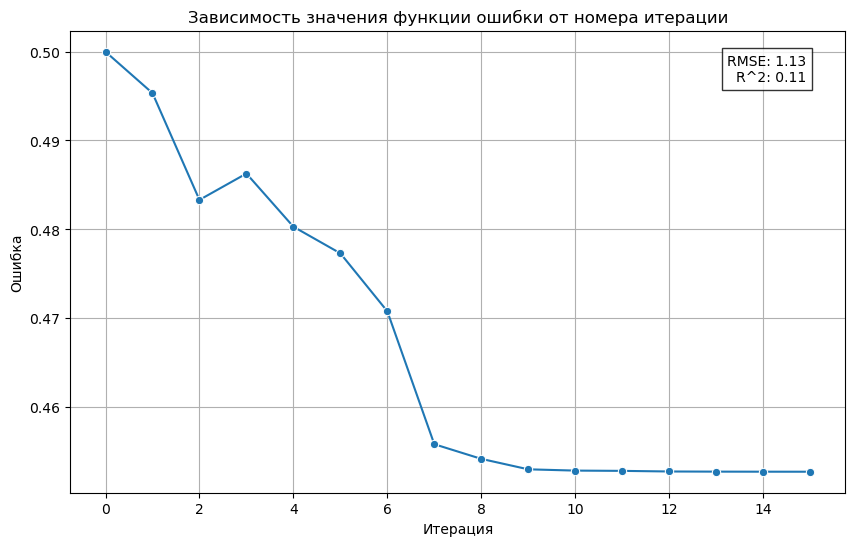

In [25]:
plot_training_summary(cv_model)

#### Проверка обобщающей способности модели

Выполним предсказания на тестовой выборке. 

Перегруппируем колонки датафрейма, переставив столбец с ценой автомобиля в конец, чтобы его значения было удобно сравнивать с предсказанными.

In [26]:
# Получаем датасет предсказаний
test_df_predictions = cv_model.transform(test_df)

# Извлекаем список колонок, устанавливаем цену на последнее место
right_columns_order = test_df_predictions.columns
right_columns_order.remove("review_score")
right_columns_order.append("review_score")

# Изменяем последовательность колонок и выводим датафрейм
test_df_predictions = test_df_predictions.select(*right_columns_order)
print_df(test_df_predictions)

,id,title,authors,publisher,published_date,categories,review_text,review_summary,review_helpfulness,review_time,user_id,profile_name,helpfulness_numerator,helpfulness_denominator,helpfulness_ratio,published_date_clean,authors_array,categories_array,published_year,author_count,category_count,is_helpful,has_multiple_authors,has_multiple_categories,is_recent_review,review_text_length,review_summary_length,title_length,review_year,review_month,publisher_type,main_category,publisher_index,categories_index,publisher_ohe,categories_ohe,numeric_vector,numeric_vector_scaled,features,prediction,review_score
0,0001047655,The Prodigal Daughter,['Jeffrey Archer'],St. Martin's Paperbacks,2004-05-16,['Fiction'],I had just finished Kane & Abel and thought the continuing story line of this family would be great. I have gotten through 70% of the book and I'm bored solid and there's not one character in the book that I can say I even like (or don't like). They're all dull. I've read all of Nelson DeMille and David Baldacci and I thought I would try a new author. My search continues.,Boring and Dull,1/1,1340755200,A34ON3UFYTPS7B,Virginia,1,1,1.00,None,['Jeffrey Archer'],['Fiction'],0,1,1,1,0,0,1,374,15,21,2012,6,other,fiction,130.00,0.00,"(32407,[130],[1.0])","(26644,[0],[1.0])","[1340755200.0,1.0,1.0,1.0,1.0,1.0]","[1.395147320527385,-0.2108314188153067,-0.2734669440363791,1.1793556091086188,0.14968066869639887,0.4534989512999961]","(59061,[130,32407,59051,59054,59055,59056,59057,59058,59059,59060],[1.0,1.0,1.0,1.0,1.395147320527385,-0.2108314188153067,-0.2734669440363791,1.1793556091086188,0.14968066869639887,0.4534989512999961])",4.27,1.00
1,0001047655,The Prodigal Daughter,['Jeffrey Archer'],St. Martin's Paperbacks,2004-05-16,['Fiction'],I kept waiting for something exciting to happen. By the time I realized I had made a mistake starting this book I had so much time invested that I was determined to finish it. A very long book with little to keep you interested and every predicament had a predictable outcome.,Wasted Hours.,1/1,1337817600,A1W7NSXZOHXPYK,Darrel,1,1,1.00,None,['Jeffrey Archer'],['Fiction'],0,1,1,1,0,0,1,276,13,21,2012,5,other,fiction,130.00,0.00,"(32407,[130],[1.0])","(26644,[0],[1.0])","[1337817600.0,1.0,1.0,1.0,1.0,1.0]","[1.3755004858872162,-0.2108314188153067,-0.2734669440363791,1.1793556091086188,0.14968066869639887,0.4534989512999961]","(59061,[130,32407,59051,59054,59055,59056,59057,59058,59059,59060],[1.0,1.0,1.0,1.0,1.3755004858872162,-0.2108314188153067,-0.2734669440363791,1.1793556091086188,0.14968066869639887,0.4534989512999961])",4.27,1.00
2,0001047655,The Prodigal Daughter,['Jeffrey Archer'],St. Martin's Paperbacks,2004-05-16,['Fiction'],"""Well, first of all I have to tell you that I don't have anything against Jeffrey Archer, I read from him the eleventh commandment (an excellent book) I didn't read Kane & Abel but I saw the picture, I didn't like that picture because I am not agree to send away your son because you hate his father in law, of course there is a Spanish saying """"Never say you will never drink of this water""""",The second part of the book is better,2/2,1032739200,A2RPIGO3G4M6GN,Jorge Frid,2,2,1.00,None,['Jeffrey Archer'],['Fiction'],0,1,1,1,0,0,0,392,37,21,2002,9,other,fiction,130.00,0.00,"(32407,[130],[1.0])","(26644,[0],[1.0])","[1032739200.0,2.0,2.0,1.0,1.0,1.0]","[-0.6648810763020637,-0.15456066362516838,-0.22663312593463134,1.1793556091086188,0.14968066869639887,0.4534989512999961]","(59061,[130,32407,59051,59055,59056,59057,59058,59059,59060],[1.0,1.0,1.0,-0.6648810763020637,-0.15456066362516838,-0.22663312593463134,1.1793556091086188,0.14968066869639887,0.4534989512999961])",4.28,3.00
3,0001047655,The Prodigal Daughter,['Jeffrey Archer'],St. Martin's Paperbacks,2004-05-16,['Fiction'],"I was happy to read this book because it was so hard to come to the end of its predecessor, Kane and Abel. The latter was a better book and in Daughter there seemed to be a lot of formulaic replays in present

Создадим функцию оценки модели: расчета метрик для некоторого датасета, как правило, тестового.

In [27]:
def evaluate_model(data: DataFrame, metric_name: str) -> float:
    """
    Оценивает модель с использованием указанной метрики.

    Args:
        data (DataFrame): DataFrame, содержащий предсказания и фактические метки.
        metric_name (str): Название метрики для оценки (например, "rmse", "r2").

    Returns:
        float: Значение указанной метрики.
    """
    evaluator = RegressionEvaluator(labelCol="review_score", 
                                    predictionCol="prediction", 
                                    metricName=metric_name)
    metric_value = evaluator.evaluate(data)
    return metric_value

Оценим модель на тестовой выборке.

In [28]:
test_rmse = evaluate_model(test_df_predictions, "rmse")
test_r2 = evaluate_model(test_df_predictions, "r2")

print(f"RMSE on test data: {test_rmse:.2f}")
print(f"R^2 on test data: {test_r2:.2f}")

RMSE on test data: 1.14
R^2 on test data: 0.11


Метрики весьма неплохие для линейной модели!

#### Сохранение модели

Зададим директорию, в которой будет сохранена обученная модель.

In [29]:
# Путь модели
model_path = f"lr-model"

database_name = "vasilev_database"
table_name = "books_table"

output_path = f"hdfs://namenode:9000/b/{database_name}/{model_path}"

# Сохраняем модель конвейера в HDFS
try:
    cv_model.bestModel.save(output_path)
    print(f"Модель успешно сохранена в \"{output_path}\"")
except Exception as e:
    print(f"Ошибка при сохранении модели: {e}")


Модель успешно сохранена в "hdfs://namenode:9000/b/vasilev_database/lr-model"


Не забываем завершать `Spark`-сессию.

In [30]:
spark.stop()